In [1]:
 import rdkit
print(rdkit.__version__)

2025.09.6


# 다음에 다시 공부를 시작할때 꼭 Anaconda Prompt에서 아래 순서로 입력하는 것일 잊지 말기

1. 왼쪽 괄호가 (base)인 상태에서 conda activate rdkit_study를 입력하기
=> 입력하면 (base) C:\Users\LG>conda activate rdkit_study (# 방에 들어가기)
2. 왼쪽 괄호가 (rdkit_study)로 바뀌는지 확인하고 jupyter notebook을 입력해서 주피터 실행하기
=> (rdkit_study) C:\User\LG>jupyter notebook (# 주피터 켜기)

*주피터 노트북을 사용하는 동안에는 Anaconda Prompt 창을 절대로 끄면 안된다.*
1. 창 자체가 '엔진' 역할을 한다: 주피터 노트북은 웹 브라우저(크롬 등)에서 화면을 보여주지만, 실제로 코드를 계산하고 처리하는 '엔진'은 그 검은색 창(Prompt)에서 돌아가고 있습니다.
2. 창을 끄면 연결이 끊겨요: 창을 닫는 순간 엔진이 꺼지기 때문에, 주피터 노트북에서 코드를 실행해도 아무런 반응이 없거나 "커널 연결 오류"가 뜨게 됩니다.

*작업을 다 마치고 끄고 싶을때 순서*
1. 주피터 노트북 화면에서 파일을 저장(Save)합니다.
2. 브라우저 탭(주피터 노트북 화면)을 닫습니다.
3. Anaconda Prompt 창으로 돌아와서 키보드의 Ctrl + C를 한두 번 누르면 "정말 종료하시겠습니까? (y/n)"가 뜹니다. 이때 y를 누르면 안전하게 종료됩니다.
4. 그다음에 창을 닫는다.


In [4]:
from rdkit import Chem # rdkit 모듈에서 sub 모듈인 Chem 모듈을 불러오겠다.

In [5]:
m = Chem.MolFromSmiles('Cc1ccccc1') # SMILES에서 분자 읽어들이기.

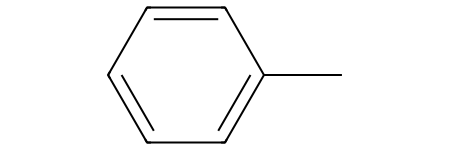

In [6]:
m

# RDKit에 molecule을 읽어들이는 방법 2개
1. Smiles
2. file

Chemial File Formats
- 화합물의 3D structure를 text file로 나타내는 방법
- chemical file는 아래와 같은 chemicals의 정보를 포함한다.
  3D: 원자들의 3D 조직
  Bond: 원자가 공유경합하는 본드
  Charge: net, partial charges
  
- File formate 종류
1) MDL mol format (SDF format)
   - 첫 두줄은 분자의 이름을 나타낸다.
   - 한줄 띄고 그 다음엔 원자와 본드의 수
     
   - 그 아래 줄은 분자의 3D coordinates으로 (Atoms block)에서 X, Y, Z coordiates, Atom symbol이 표기 되어있다. (수소가 포한되는지, 포함되지 않는지 확인해야함. 많은 데이터베이스가 수소를 빼놓고 정보를 가지는 경우가 많기 때문. 수소 없는 상태에서 계산을 돌리면 잘못되는 경우가 있음)
   - 그 아래 줄은 bond 정보 (Bonds block)에서 4줄이 있는데 첫줄을 해석해보자면 1210 첫번째 숫자는 first atome row number, 두번째 숫자는 second atom row number, 세번째 숫자는 bond type, 마지막 네번째 숫자는 bond stereochemistry 에 대한 정보를 담고 있기때문에 '1210'은 첫번째 원자와 두번째 원자는 단일 결합으로 이루어져있다.'로 해석할 수 있다.
     stereochemistry에서 6은 화학 구조식에서 dashed(빗금, 뒤로 들어간 구조)를, 1은 wedged(색칠된, 앞으로 튀어나온 구조)를 의미한다. 그리고 이러한 chiral은 두번째 줄의 원자와 본드 수에 대한 정보에서 '1'로 표기한다.
     
2) Sybyl mol2 format (리간드 docking에 있어서 많이 사용되는 포멧=>partial charge에 대한 정보가 포함되어있기 때문)
    - @<TRIPOS>MOLECULE
      분자명(benzene)
      (atom 개수) (bond 개수)
      atom의 종류
      atom의 charge에 대한 정보 기입 가능

      @<TRIPOS>ATOM
      분자를 이루는 atom에 대한 정보
      1 column(index)/ 2 column(atom name) / 3~5 column(X, Y, Z 정보) / 6 column(atom type) / 7 column(partia lcharge)
      *atom type은 Tripos Atomtypes에 근거한다.(구글에 검색하면 나옴)*
      @<TRIPOS>BOND
      각 원자 사이의 본드 정보
      1 colunm(index)/ 2 column(시작되는 원자의 index)/ 3 column(2 column에 연결된 원자와의 index)/ 4 column(bond 종류)

    - mol2 format을 사용할때는 chemdraw와 같은 visualize program으로 mol2 file을 생성한다고해도 mol2 file의 atom type이 잘못 지정되어있는 경우가 많기 때문에 mol2 file을 사용할때는 atomtype이 제대로 지정되어있는지 확인해야한다.

3) xyz format (양자화학 계산, 가오시안 계산)
- 가오시안 같은 퀀텀 계산을 할때 주로 사용되는 퀀텀 계산같은 경우에는 covelent bond에 관한 정보는 양자역학적으로 계산이되도로하기때문에 bond information을 명시적으로 표현할필요 없다.
- 따라서 원자의 정보(atomic symbol)와 x, y, z coordinate의 정보만 표현하면된다.
  First lne: 원자의 수 (12)
  Second line: 분자의 이름 (benzene)
  rest of the line: atomic symbol, x, y, z coordinates
  
4) pdb format; Protein Data Bank (단백질 구조를 나타낼때, small molecule 나타낼때도 종종 사용)

SMILES notation

1차원 표시방법으로 3차원 구조 반영하지 않는다.

Atoms: 원자들의 고유한 symbol로 나타낸다. ex) C: carbon, F: Fluorine ...

Bonds: single bond (-), double bond (=), Triple bond(#), Aromatic (:)

* Examples
  Methans(CH4)                     => C
  Propane(CH3-CH2-CH3)             => CCC
  Chloroethane(CH3-CH2-Cl)         => CCCl
  Ethene(CH2=CH2)                  => C=C
  Bromoethene(CHBr=CH2)            => BrC=C
  Acethelyne(CHCH)                 => C#C
  Acetonitrile(CH3CN)              => CC#N

Branches: parentheses(괄호)로 표시
* EXamples
  2-propanol (CH3CHOHCH3)        => CC(O)C       # 즉, 가지로 뻗어진 원자에 괄호를 친다.
  Tert-butanol (CH3CCH3OHCH3)    => CC(C)(O)C
  Isobutyric acid (CH3CHCH3COOH) => CC(C)C(=O)O  # Main chain을 정하고(임의로) 그것에 대한 smiles가 생기기때문에 한 분자에 대하여 여러개의 smiles가 생성될 수 있다.
  3-isopropyl-3tert-butyl-1-pentena
  => Main chain 정하고 branch 안에 또 다른 branch 가 생길수 있다 그럴때 괄호 안에 또다른 괄호를 넣으면된다. C=CC(C(C)C)(C(C)(C)C)CC

Cyclic structures: ring 구조 표현
- C6H12의 cyclic structure의 경우 C1CCCCC1 원소 기호 뒤에 숫자를 나타내어 링으로 만나는 원자끼리 같은 숫자를 부여함으로써 두 원자가 실제 구조에서 연결됨을 표시한다.
- 뱡항족의 경우 소문자로 원소 기호 표시하며 bond 정보는(=) 표기하지 않는다.

- Ring이 두개 이상일때는 숫자를 두개를 사용한다.
  ex) Naphthalene: c1ccc2ccccc2c1 / c12ccccc1cccc2 / c2cccc1ccccc12
      Brc1c(Br)c(Br)c(Br)c(Br)c1(Br)

<SMILES 요약>
1. ring 구조가 끊어진 것으로 간주하고(ring을 임의의 구간에서 끊어버리기)
2. 가장 긴 chain(Main chain)을 찾는다.
3. Main chain을 제외한 다른 bond는 branch로 생각하고 링이 닫히는 부분들을 숫자의 pair로 표현한다.

In [2]:
import os; print(os.listdir('.'))

['.ipynb_checkpoints', 'data', 'RDKit 1강.ipynb']


성공! 분자 구조를 불러왔습니다.


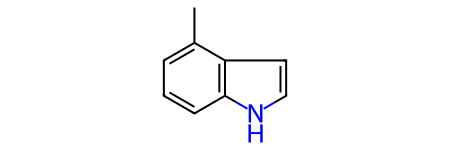

In [4]:
from rdkit import Chem

# 이제 Chem 도구를 사용할 수 있습니다!
m2 = Chem.MolFromMolFile('data/input.mol')

# 잘 불러와졌는지 확인
if m2:
    print("성공! 분자 구조를 불러왔습니다.")
    display(m2)
else:
    print("파일 내용은 읽었으나 분자 구조가 생성되지 않았습니다 (파일 내용 확인 필요)")

In [5]:
print(m2)

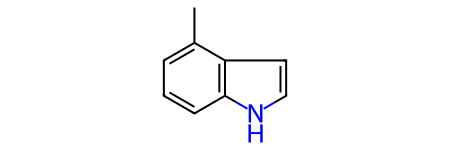

In [6]:
m2

In [9]:
from rdkit import Chem # rdkit 모듈에서 sub 모듈인 Chem 모듈을 불러오겠다.

In [10]:
m = Chem.MolFromSmiles('Cc1ccccc1') # SMILES에서 분자 읽어들이기.

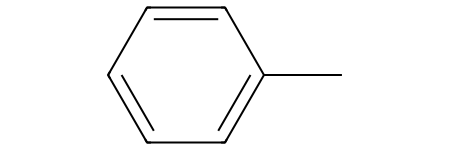

In [11]:
m

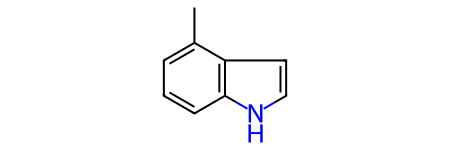

In [12]:
m2

In [17]:
m3 = Chem.MolFromMolFile("data/invalid.mol")

[17:26:01] EOF hit while reading bonds


In [18]:
m3 is None

True

In [19]:
type(m3) #파이썬에서 아무것도 없을때 고유한 NoneType이라는 것을 정의한다.

NoneType

In [20]:
m1 = Chem.MolFromSmiles('CO(C)C')

[17:28:19] Explicit valence for atom # 1 O, 3, is greater than permitted


<위 에러 해석>
샵 1 O, 3 => 1번 atom이 oxygen, 3개의 bond라는 의미인데 explicit valence 즉, 산소가 가질 수 있는 bond의 수를 넘어섰기때문에 문제가 있다는 것을 알려줌.

하나의 파일에 여러 분자에 대한 정보를 넣어 줄수 있음(각각의 분자를 독립된 하나의 파일에 저장하기엔 번거로움)
=> 이럴때 supplier를 정의할 수 있다.

In [24]:
suppl = Chem.SDMolSupplier('data/5ht3ligs.sdf') #SDF file format (Mole File format과 동일)의 파일을 읽어들임.

In [25]:
type(suppl)

rdkit.Chem.rdmolfiles.SDMolSupplier

In [28]:
mols = []
for mol in suppl:
    mols.append(mol)
    print(mol.GetNumAtoms()) #분자 안에 존재하는 원자의 개수

20
24
24
26


In [29]:
mols # 4개의 분자를 가지는 리스트

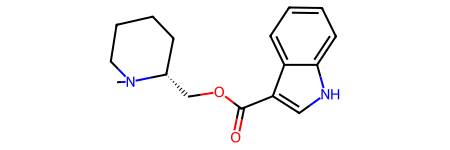

In [31]:
mols[0] #프로그래밍 언어는 숫잘르 셀때 0부터 시작하는 '제로 기반 인덱싱(Zero-based Indexing)' 즉, mols[0]은 1번째 분자, mols[4]는 3번째 분자로 mols[n-1]은 n번째 분자를 의미한다.

SDF 파일에 있는 분자들을 하나씩 불러들이는 과정

mols = []
비어있는 리스트를 만든다. (SDF 파일에서 꺼낸 분자들을 나중에 한꺼번에 모아서 관리하기 위해 미리 준비해두는 공간)

for mol in suppl:
suppl(분자 묶음 공급자) 안에 들어있는 분자들을 하나씩 차례대로 꺼내서 mol이라는 이름으로 부르겠다. (SDF 파일은 분자가 여러 개 들어있는 묶음이기 때문에, for 문으 ㄹ써서 첫 번째 분자부터 마지막 분자까지 반복해서 작업 수행)

mols.append(mol)
방금 꺼낸 분자(mol)를 아가 만든 비어있는 리스트(mols)에 추가(append)한다. (반복문이 끝나도 이 분자들을 계속 사용할 수 있도록 리스트에 차곡차곡 쌓아두는 것)
  *python에서 append는 리스트, 배열의 맨 마지막에 새로운 요소나 데이터를 추가하는 함수

print(mol.GetNumAtoms())
현재 꺼낸 분자(mol)가 가지고 있는 원자의 총 개수(GetNumAtoms)를 화면에 출력한다. (각 분자가 얼마나 큰지, 원자가 몇 개인지 실시간으로 확인하기 위한 코드)

* 요약 *
파일 뭉치(suppl)에서 분자를 하나씩 꺼내(for mol in...), 내 바구니에 담고(append), 그 분자의 원자 개수를 숫자로 보여줘(print)

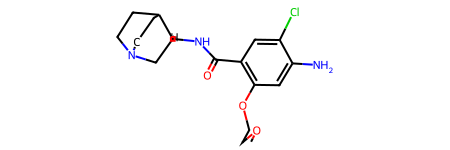

In [32]:
mols[1]

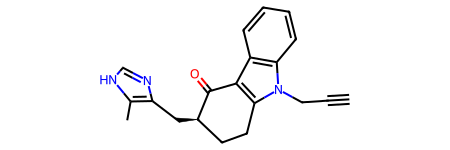

In [33]:
mols[2]

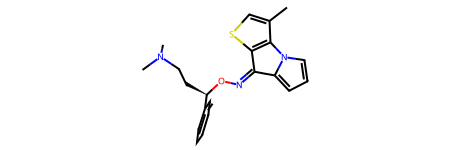

In [34]:
mols[3]

위의 구조를 보면 삐뚤어져있는 부분도 있는데, 이건 SDF file이 x, y, z의 입체 정보를 포함하고 있어서 이것을 2차원에 반영하다보니 생기는 것

In [35]:
import gzip #.gz로 압축되어 있는 경우, .bz2 압축되어 있는 경우에는 import bz2를 사용해야함.

In [36]:
fp = gzip.open('data/actives_5ht3.sdf.gz', 'rb') # gz 으로 압축된 분자 파일을 읽는다. #"rb"를 표시해줘야 binary 파일을 읽는다는 것을 표현.

In [37]:
with Chem.ForwardSDMolSupplier(fp) as suppl:
    all_mols = [m for m in suppl if m is not None] # 에러가 있는 분자는 제외하고 에러가 없는 분자들만 supplier에서 읽어들여서 리스트로 만들겠다.

In [38]:
len(all_mols)

180

읽어들인 분자를 저장할때 분자를 SMILES 혹은 File로 표현해야한다.

Chem.MolFromMolFile("data/invalid.mol")
=> 이건 파일을 불러들일때 'From'

반대로 내보낼때는 'To'
Chem.MolToMolFile(m2)

m2

In [42]:
Chem.MolToSmiles(m2) # canonical SMILES(하나의 분자에 여러 SMILES code가 존재하는데 이 중 가장 긴 main chain으로 정리된 코드) 로 내보내게 됨. 

'Cc1cccc2[nH]ccc12'

하나의 분자를 여러개의 smiles로 나타낼 수 있음의 예

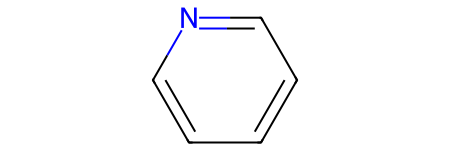

In [48]:
Chem.MolFromSmiles('C1=CC=CN=C1')
# 싱글본드(단일 결합)와 더블본드(이중 결합)가 반복해서 나타나는 케큘레 구조 (Kekulé structure)

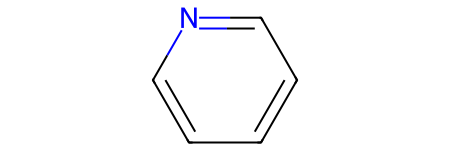

In [50]:
Chem.MolFromSmiles('c1cccnc1')
# aromatic structure

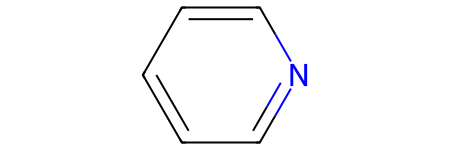

In [51]:
Chem.MolFromSmiles('n1ccccc1')
# 동일한 aromatic structure라도 어디에서 시작하느냐에 따라 다른 SMILES가 생성된다.

MolToSmiles에 넣으면 모두 canocical structure로 변환된다.

In [52]:
Chem.MolToSmiles(Chem.MolFromSmiles('C1=CC=CN=C1'))

'c1ccncc1'

In [53]:
Chem.MolToSmiles(Chem.MolFromSmiles('c1cccnc1'))

'c1ccncc1'

In [54]:
Chem.MolToSmiles(Chem.MolFromSmiles('n1ccccc1'))

'c1ccncc1'

In [55]:
m4 = Chem.MolFromSmiles('n1ccccc1')

In [56]:
# 케큘러 구조로 표현하고자한다면
Chem.Kekulize(m4)

In [59]:
Chem.MolToSmiles(m4, kekuleSmiles=True) # Kekule form으로 출력하게 됨.

'C1=CC=NC=C1'

MolToXYZFile, MoleToPDBFile
MolToMolBlock # 분자를 mol file로 출력

In [61]:
Chem.MolToMolFile(m4, "data/test.mol") # m4를 test.mol 파일로 저장하겠다.

In [63]:
Chem.MolToPDBFile(m4, "data/test.pdb") #m4를 test.pdb 파일로 저장하겠다.

In [64]:
# "SetProp" 는 분자의 성질을 임의로 정의할 수 있다.

- dir() 이용하여 Mol-type 변수가 가지고 있는 method와 attribute를 확인. 
- dir(): 객체(변수, 모듈, 함수, 클래스 등)가 가진 속성(attribute)과 메서드(method) 목록을 알파벳 순서의 리스트로 반환하는 내장 함수

In [65]:
dir(m4)

['AddConformer',
 'ClearComputedProps',
 'ClearProp',
 'ClearPropertyCache',
 'Debug',
 'GetAromaticAtoms',
 'GetAtomWithIdx',
 'GetAtoms',
 'GetAtomsMatchingQuery',
 'GetBondBetweenAtoms',
 'GetBondWithIdx',
 'GetBonds',
 'GetBoolProp',
 'GetConformer',
 'GetConformers',
 'GetDoubleProp',
 'GetIntProp',
 'GetNumAtoms',
 'GetNumBonds',
 'GetNumConformers',
 'GetNumHeavyAtoms',
 'GetProp',
 'GetPropNames',
 'GetPropsAsDict',
 'GetRingInfo',
 'GetStereoGroups',
 'GetSubstructMatch',
 'GetSubstructMatches',
 'GetUnsignedProp',
 'HasProp',
 'HasQuery',
 'HasSubstructMatch',
 'NeedsUpdatePropertyCache',
 'RemoveAllConformers',
 'RemoveConformer',
 'SetBoolProp',
 'SetDoubleProp',
 'SetIntProp',
 'SetProp',
 'SetUnsignedProp',
 'ToBinary',
 'UpdatePropertyCache',
 '__DebugMol',
 '__GetSubstructMatch',
 '__GetSubstructMatches',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getinita

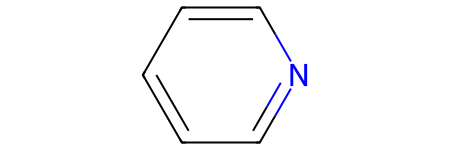

In [66]:
m4

In [68]:
m4.SetProp("_Name","my_molecule") # m2.SetProp("_Name","cyclobutane")

In [73]:
print(Chem.MolToMolBlock(m4)) # name이 my_molecule로 정의되었다.

my_molecule
     RDKit          2D

  6  6  0  0  0  0  0  0  0  0999 V2000
    1.5000    0.0000    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    0.7500   -1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7500   -1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.5000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7500    1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7500    1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  2  0
  2  3  1  0
  3  4  2  0
  4  5  1  0
  5  6  2  0
  6  1  1  0
M  END

